In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [14]:
df = pd.read_csv("data/wiki_web_flow.csv", index_col="Page")


In [9]:
df.head(20)

,Page,2015-07-01,2015-07-02,2015-07-03,2015-07-04,2015-07-05,2015-07-06,2015-07-07,2015-07-08,2015-07-09,...,2017-09-01,2017-09-02,2017-09-03,2017-09-04,2017-09-05,2017-09-06,2017-09-07,2017-09-08,2017-09-09,2017-09-10
0,2NE1_zh.wikipedia.org_all-access_spider,18.0,11.0,5.0,13.0,14.0,9.0,9.0,22.0,26.0,...,19.0,33.0,33.0,18.0,16.0,27.0,29.0,23.0,54.0,38.0
1,2PM_zh.wikipedia.org_all-access_spider,11.0,14.0,15.0,18.0,11.0,13.0,22.0,11.0,10.0,...,32.0,30.0,11.0,19.0,54.0,25.0,26.0,23.0,13.0,81.0
2,3C_zh.wikipedia.org_all-access_spider,1.0,0.0,1.0,1.0,0.0,4.0,0.0,3.0,4.0,...,6.0,6.0,7.0,2.0,4.0,7.0,3.0,4.0,7.0,6.0
3,4minute_zh.wikipedia.org_all-access_spider,35.0,13.0,10.0,94.0,4.0,26.0,14.0,9.0,11.0,...,7.0,19.0,19.0,9.0,6.0,16.0,19.0,30.0,38.0,4.0
4,52_Hz_I_Love_You_zh.wikipedia.org_all-access_s...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,16.0,16.0,19.0,9.0,20.0,23.0,28.0,14.0,8.0,7.0
5,5566_zh.wikipedia.org_all-access_spider,12.0,7.0,4.0,5.0,20.0,8.0,5.0,17.0,24.0,...,13.0,13.0,45.0,4.0,13.0,20.0,18.0,17.0,14.0,11.0
6,91Days_zh.wikipedia.org_all-access_spider,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,12.0,8.0,5.0,7.0,8.0,10.0,8.0,5.0,3.0,5.0
7,A'N'D_zh.wikipedia.org_all-access_spider,118.0,26.0,30.0,24.0,29.0,127.0,53.0,37.0,20.0,...,74.0,39.0,11.0,55.0,71.0,44.0,25.0,39.0,25.0,50.0
8,AKB48_zh.wikipedia.org_all-access_spider,5.0,23.0,14.0,12.0,9.0,9.0,35.0,15.0,14.0,...,53.0,107.0,63.0,42.0,24.0,44.0,33.0,52.0,21.0,48.0
9,ASCII_zh.wikipedia.org_all-access_spider,6.0,3.0,5.0,12.0,6.0,5.0,4.0,13.0,9.0,...,20.0,16.0,22.0,19.0,21.0,32.0,34.0,29.0,23.0,25.0


In [15]:
df.info()

<class 'pandas.DataFrame'>
Index: 145063 entries, 2NE1_zh.wikipedia.org_all-access_spider to Francisco_el_matemático_(serie_de_televisión_de_2017)_es.wikipedia.org_all-access_spider
Columns: 803 entries, 2015-07-01 to 2017-09-10
dtypes: float64(803)
memory usage: 889.8+ MB


In [16]:
#all dates to date time
df.columns = pd.to_datetime(df.columns)

7,027,348 NaN (6.0%)


<Axes: title={'center': 'Share of pages missing, by date'}>

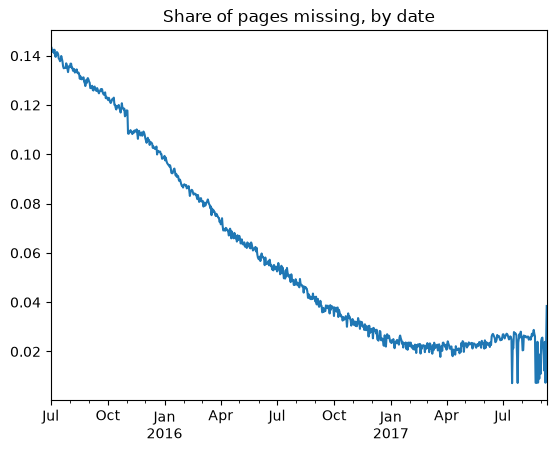

In [18]:
# how much is missing, and where
na = df.isna()
print(f"{na.sum().sum():,} NaN ({na.mean().mean():.1%})")
na.mean().plot(title="Share of pages missing, by date")

In [19]:
# classify each NaN as leading / internal / trailing
filled_fwd = df.ffill(axis=1).notna()          # True after first real value
filled_bwd = df.bfill(axis=1).notna()          # True before last real value
leading  = na & ~filled_fwd
trailing = na & ~filled_bwd
internal = na & filled_fwd & filled_bwd
print(leading.sum().sum(), internal.sum().sum(), trailing.sum().sum())

4736654 2033594 257100


In [ ]:
# split the Page name into its parts
parts = df.index.str.extract(r"^(.*)_([^_]+)_([^_]+)_([^_]+)$")
parts.columns = ["article", "project", "access", "agent"]
parts.index = df.index
parts["nan_share"] = na.mean(axis=1)
parts.groupby("project")["nan_share"].mean().sort_values(ascending=True)

project
es.wikipedia.org         0.027378
fr.wikipedia.org         0.032605
ru.wikipedia.org         0.033778
ja.wikipedia.org         0.041883
de.wikipedia.org         0.043381
en.wikipedia.org         0.056391
zh.wikipedia.org         0.075706
www.mediawiki.org        0.136956
commons.wikimedia.org    0.185169
Name: nan_share, dtype: float64

In [24]:
# unusual values: the biggest cells and the spikiest pages
print(df.stack().nlargest(10))
med = df.median(axis=1)
spikiness = df.max(axis=1) / med.replace(0, np.nan)
spikiness.sort_values(ascending=False).head(10)   # needs: import numpy as np

Page                                                        
Main_Page_en.wikipedia.org_all-access_all-agents  2016-07-26    67264258.0
                                                  2016-07-25    67122896.0
                                                  2016-08-01    66131225.0
                                                  2016-07-27    65155635.0
                                                  2016-07-28    64355899.0
                                                  2016-08-02    63079604.0
                                                  2016-08-15    63052818.0
Main_Page_en.wikipedia.org_desktop_all-agents     2016-07-26    62288712.0
Main_Page_en.wikipedia.org_all-access_all-agents  2016-07-31    62260676.0
Main_Page_en.wikipedia.org_desktop_all-agents     2016-07-25    62174277.0
dtype: float64


Page
"European_Society_for_Clinical_Investigation"_en.wikipedia.org_desktop_all-agents                                                  1.567861e+06
"European_Society_for_Clinical_Investigation"_en.wikipedia.org_all-access_all-agents                                               1.567861e+06
Special:WhatLinksHere/File:National_Park_Service_9-11_Statue_of_Liberty_and_WTC_fire.jpg_en.wikipedia.org_all-access_all-agents    6.189600e+05
MediaWiki:Wikibugs.js_ru.wikipedia.org_desktop_all-agents                                                                          5.051300e+05
Special:WhatLinksHere/File:National_Park_Service_9-11_Statue_of_Liberty_and_WTC_fire.jpg_en.wikipedia.org_desktop_all-agents       4.951190e+05
!vote_en.wikipedia.org_all-access_all-agents                                                                                       3.869200e+05
!vote_en.wikipedia.org_desktop_all-agents                                                                                          

<Axes: >

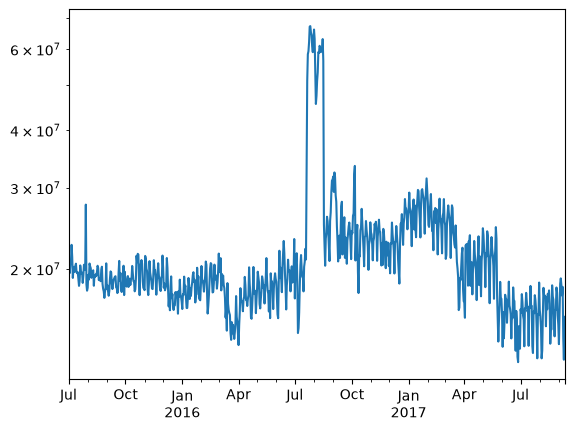

In [25]:
# plot one page to see what a spike looks like
df.loc["Main_Page_en.wikipedia.org_all-access_all-agents"].plot(logy=True)


/var/folders/sz/3_np9r_91db6_dhc9819tkwh0000gn/T/ipykernel_5233/2238468713.py:14: UserWarning: Glyph 22823 (\N{CJK UNIFIED IDEOGRAPH-5927}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/sz/3_np9r_91db6_dhc9819tkwh0000gn/T/ipykernel_5233/2238468713.py:14: UserWarning: Glyph 22618 (\N{CJK UNIFIED IDEOGRAPH-585A}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/sz/3_np9r_91db6_dhc9819tkwh0000gn/T/ipykernel_5233/2238468713.py:14: UserWarning: Glyph 22269 (\N{CJK UNIFIED IDEOGRAPH-56FD}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/sz/3_np9r_91db6_dhc9819tkwh0000gn/T/ipykernel_5233/2238468713.py:14: UserWarning: Glyph 38555 (\N{CJK UNIFIED IDEOGRAPH-969B}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/sz/3_np9r_91db6_dhc9819tkwh0000gn/T/ipykernel_5233/2238468713.py:14: UserWarning: Glyph 32654 (\N{CJK UNIFIED IDEOGRAPH-7F8E}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/sz/3_np9r_91

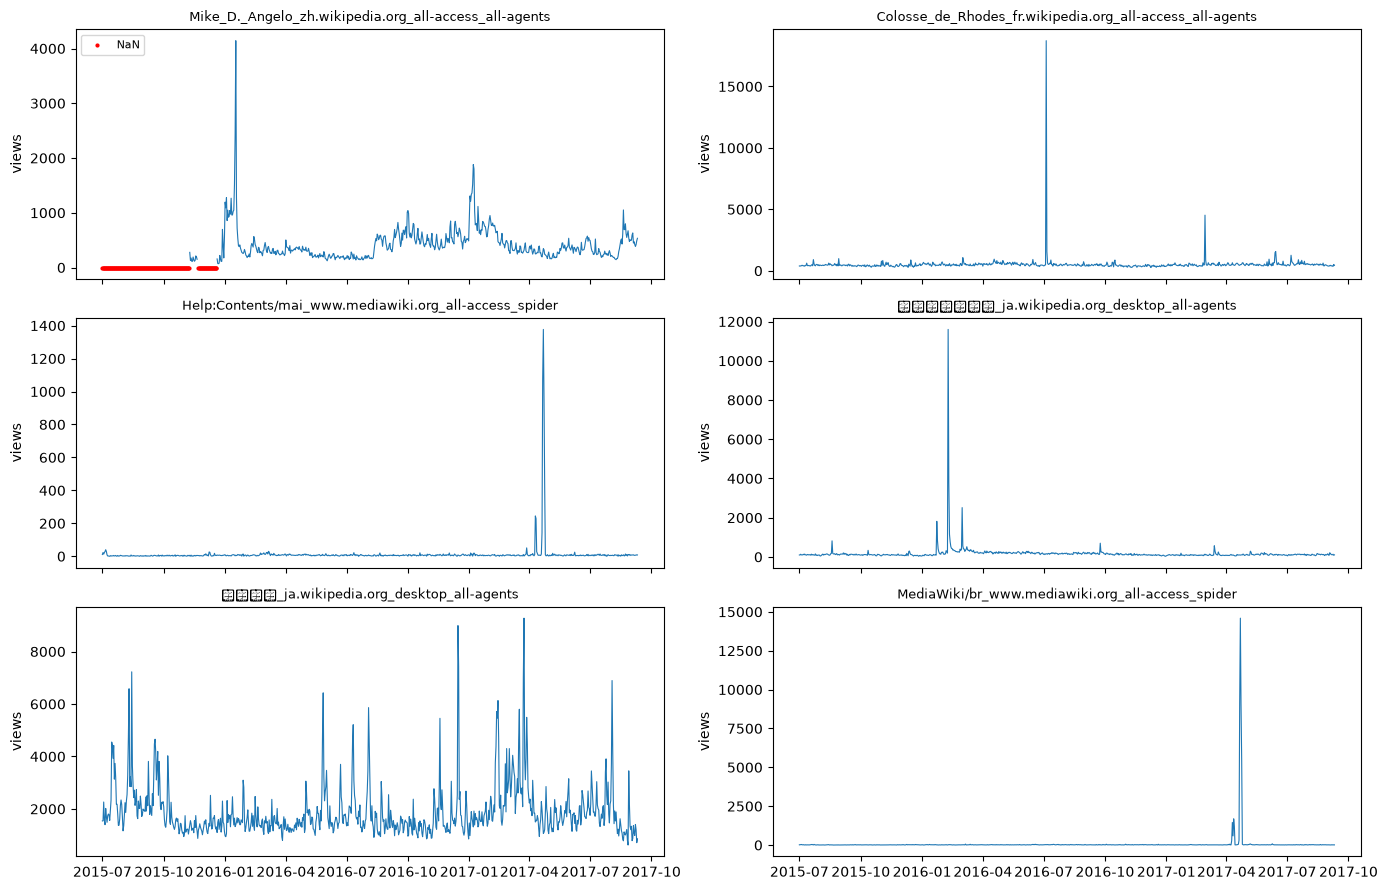

In [28]:

sample = df.sample(6)            # add random_state=42 to get the same 6 pages every run

fig, axes = plt.subplots(3, 2, figsize=(14, 9), sharex=True)
for ax, (page, series) in zip(axes.flat, sample.iterrows()):
    ax.plot(series.index, series.values, lw=0.8)
    missing = series.isna()
    ax.scatter(series.index[missing], [0] * missing.sum(),
               color="red", s=4, label="NaN")        # missing days shown as red dots
    ax.set_title(page, fontsize=9)
    ax.set_ylabel("views")
    if missing.any():
        ax.legend(loc="upper left", fontsize=8)

fig.tight_layout()
plt.show()

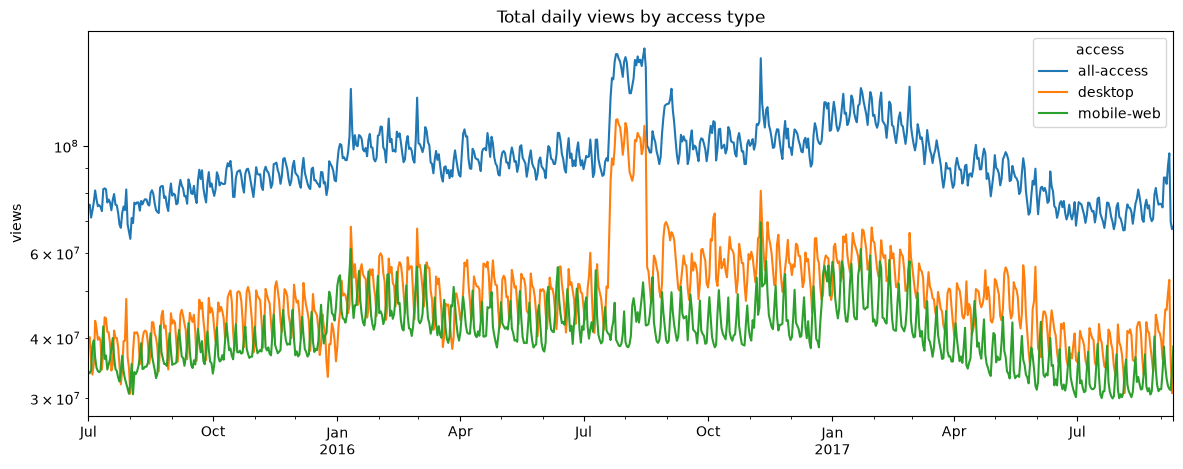

In [29]:
import matplotlib.pyplot as plt

views_by_access = df.groupby(parts["access"]).sum().T   # rows = dates, columns = access type
views_by_access.plot(figsize=(14, 5), logy=True, title="Total daily views by access type")
plt.ylabel("views")
plt.show()

## intestigating the spike 🕵

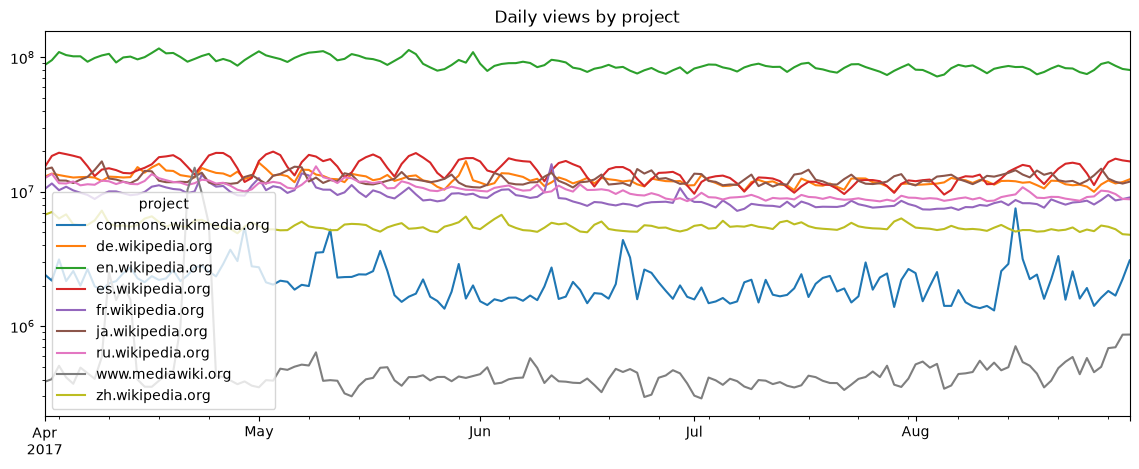

In [30]:
# 1. total views per project, to see which project spikes
window = df.loc[:, "2017-04-01":"2017-08-31"]
by_project = window.groupby(parts["project"]).sum().T
by_project.plot(figsize=(14, 5), logy=True, title="Daily views by project")
plt.show()

In [31]:
# 2. which pages jumped most in Jun–Jul 2017, compared with their own Mar–May median
base = df.loc[:, "2017-03-01":"2017-05-31"].median(axis=1)
summer = df.loc[:, "2017-06-01":"2017-07-31"]
jump = (summer.max(axis=1) - base).nlargest(15)
pd.DataFrame({"jump": jump,
              "normal": base[jump.index],
              "peak_day": summer.loc[jump.index].idxmax(axis=1)})


,jump,normal,peak_day
Page,,,
Special:Search_en.wikipedia.org_desktop_all-agents,2841946.5,1609632.5,2017-06-01
Special:Search_en.wikipedia.org_all-access_all-agents,2669534.0,2464098.0,2017-06-01
Special:CreateAccount_en.wikipedia.org_all-access_all-agents,1392975.0,119704.0,2017-06-07
Tony_Romo_en.wikipedia.org_all-access_all-agents,1309510.5,3728.5,2017-06-01
小林麻央_ja.wikipedia.org_all-access_all-agents,1297545.0,2737.0,2017-06-23
Special:CreateAccount_commons.wikimedia.org_all-access_all-agents,1205651.5,193826.5,2017-06-21
Special:CreateAccount_en.wikipedia.org_all-access_spider,1181061.0,16845.0,2017-06-07
Special:CreateAccount_commons.wikimedia.org_desktop_all-agents,1040020.5,178528.5,2017-06-21
小林麻央_ja.wikipedia.org_mobile-web_all-agents,1026929.5,2156.5,2017-06-23


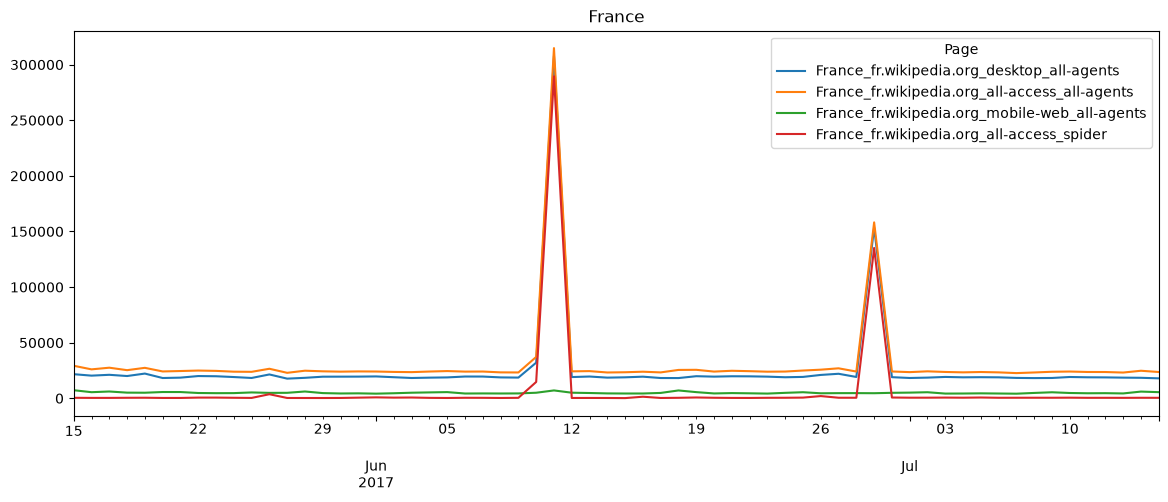

In [32]:
# 3. zoom into one spike and compare all versions of the article (bots vs people)
article = "France"
rows = parts.index[(parts["article"] == article) & (parts["project"] == "fr.wikipedia.org")]
df.loc[rows, "2017-05-15":"2017-07-15"].T.plot(figsize=(14, 5), title=article)
plt.show()